In [1]:
import scanpy as sc
import anndata as ad
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# load anndata objects
adata = sc.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_harmony_celloracle_compatible.h5ad')
adata

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 86672 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid', '_scvi_uui

### Filter out low quality cells with very little genes expressed

In [3]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[:, (~adata.var['mt'] & ~adata.var['ribo'] & ~adata.var['hb'])] # Filter mitochondrial, ribosomal, haemoglobin genes
print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Number of cells after filtering of low quality cells: 81614


/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


#### Visualize the cells

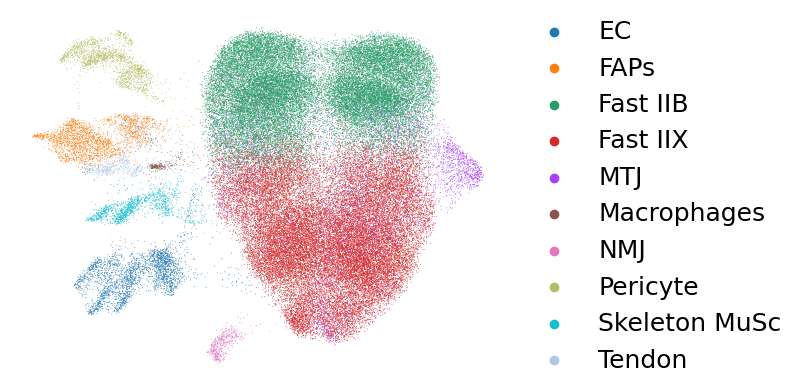

In [4]:
#umap colors by both cell metadata and var.names (gene_names)
sc.pl.umap(adata, color=['C_scANVI'], frameon=False, legend_fontsize=18,
           legend_fontweight='bold', legend_fontoutline=2, title='')

#### Visualize the distribution of gene expression (mRNA) counts across all the cells, before log norm (raw) and after log norm

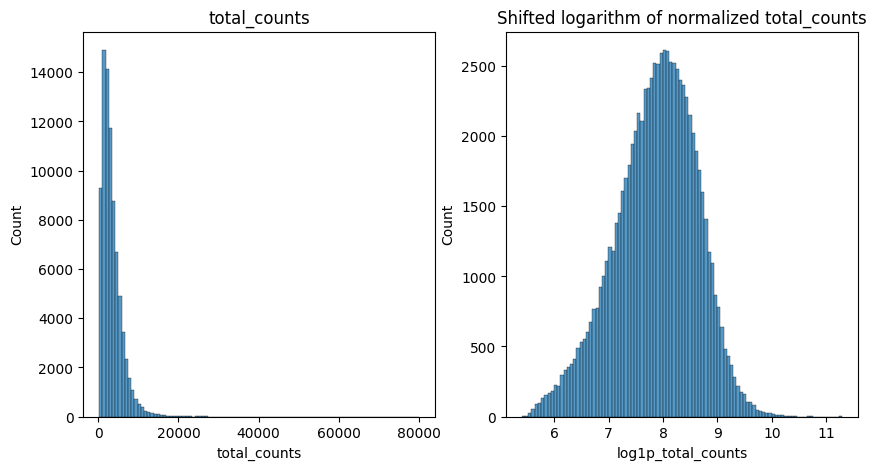

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("total_counts")
sns.histplot(adata.obs["log1p_total_counts"], bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm of normalized total_counts")
plt.show()

### We are interested in doing gender specific analysis

In [6]:
male_adata_subset = adata[adata.obs['sex'] == 'M']
female_adata_subset = adata[adata.obs['sex'] == 'F']

### Get DEGs for each cell type between the old (ERCC1 KO) vs young (WT)

#### Set the gender of interest

In [15]:
gender_adata = male_adata_subset

In [10]:
# Run DEG analysis: KO vs WT for each cell type
cell_types = gender_adata.obs['C_scANVI'].cat.categories
ko_wt_results = {}

for cell_type in cell_types:
    print(f"\nAnalyzing {cell_type}...")
    
    # Subset to specific cell type
    cell_type_adata_subset = gender_adata[gender_adata.obs['C_scANVI'] == cell_type].copy()
    
    # Check sample sizes
    condition_counts = cell_type_adata_subset.obs['condition'].value_counts()
    print(f"  Cells per condition: {condition_counts.to_dict()}")
    
    # Check if both KO and WT exist
    if 'KO' in condition_counts.index and 'WT' in condition_counts.index:
        if condition_counts['KO'] >= 10 and condition_counts['WT'] >= 10:  # Minimum cell threshold
            
            # Run differential expression
            sc.tl.rank_genes_groups(
                cell_type_adata_subset,
                groupby='condition',
                groups=['KO'],
                reference='WT',
                method='wilcoxon',
                use_raw=False,
                pts=True,  # Calculate percent expressed
                key_added='KO_vs_WT'
            )
            
            # Extract results
            degs = sc.get.rank_genes_groups_df(cell_type_adata_subset, group='KO', key='KO_vs_WT')
            
            # Add cell type column
            degs['cell_type'] = cell_type
            
            # Store results
            ko_wt_results[cell_type] = degs
            
            # Count significant genes
            sig_up = ((degs['pvals_adj'] < 0.05) & (degs['logfoldchanges'] > 0.5)).sum()
            sig_down = ((degs['pvals_adj'] < 0.05) & (degs['logfoldchanges'] < -0.5)).sum()
            print(f"  Significant DEGs: {sig_up} upregulated, {sig_down} downregulated")
            
            # Save individual file
            #degs.to_csv(os.path.join(working_dir, f"DEGs_KO_vs_WT_{cell_type.replace(' ', '_').replace('/', '_')}.csv"), index=False)
        else:
            print(f"  Skipping - insufficient cells")
    else:
        print(f"  Skipping - missing KO or WT samples")

# Print summary table
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
for ct, degs in ko_wt_results.items():
    sig = degs['pvals_adj'] < 0.05
    up = (sig & (degs['logfoldchanges'] > 0.5)).sum()
    down = (sig & (degs['logfoldchanges'] < -0.5)).sum()
    print(f"{ct:20s} | ↑ {up:4d} | ↓ {down:4d} | Total: {len(degs):5d}")


Analyzing EC...
  Cells per condition: {'KO': 1176, 'WT': 578}
  Significant DEGs: 3 upregulated, 0 downregulated

Analyzing FAPs...
  Cells per condition: {'KO': 1013, 'WT': 686}
  Significant DEGs: 29 upregulated, 23 downregulated

Analyzing Fast IIB...
  Cells per condition: {'KO': 9536, 'WT': 6468}
  Significant DEGs: 6 upregulated, 42 downregulated

Analyzing Fast IIX...
  Cells per condition: {'KO': 7273, 'WT': 6627}
  Significant DEGs: 5 upregulated, 18 downregulated

Analyzing MTJ...
  Cells per condition: {'KO': 1377, 'WT': 909}
  Significant DEGs: 5 upregulated, 12 downregulated

Analyzing Macrophages...
  Cells per condition: {'WT': 359, 'KO': 297}
  Significant DEGs: 0 upregulated, 0 downregulated

Analyzing NMJ...
  Cells per condition: {'KO': 267, 'WT': 180}
  Significant DEGs: 2 upregulated, 0 downregulated

Analyzing Pericyte...
  Cells per condition: {'KO': 741, 'WT': 383}
  Significant DEGs: 0 upregulated, 0 downregulated

Analyzing Skeleton MuSc...
  Cells per condi

In [16]:
def create_volcano_plot(degs, cell_type, top_n=10, xlim=(-5, 5), title='', save=True):
    """
    Create volcano plot for DEGs
    
    Parameters:
    -----------
    degs : DataFrame
        DEG results from scanpy
    cell_type : str
        Name of cell type
    top_n : int
        Number of top genes to label
    title : str
        Title of the plot
    save : bool
        Whether to save the plot
    """
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Calculate -log10(p-value)
    degs['-log10_padj'] = -np.log10(degs['pvals_adj'].replace(0, 1e-300))  # Handle p=0
    
    # Define significance thresholds
    pval_thresh = 0.05
    fc_thresh = 0.5
    
    # Classify genes
    degs['significant'] = 'Not Significant'
    degs.loc[
        (degs['pvals_adj'] < pval_thresh) & (degs['logfoldchanges'] > fc_thresh),
        'significant'
    ] = 'Upregulated'
    degs.loc[
        (degs['pvals_adj'] < pval_thresh) & (degs['logfoldchanges'] < -fc_thresh),
        'significant'
    ] = 'Downregulated'
    
    # Color map
    colors = {'Upregulated': '#d62728', 'Downregulated': '#1f77b4', 'Not Significant': '#7f7f7f'}
    
    # Plot points
    for category, color in colors.items():
        mask = degs['significant'] == category
        ax.scatter(
            degs.loc[mask, 'logfoldchanges'],
            degs.loc[mask, '-log10_padj'],
            c=color,
            label=category,
            alpha=0.6,
            s=20,
            edgecolors='none'
        )
    
    # Add threshold lines
    ax.axhline(-np.log10(pval_thresh), color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(fc_thresh, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(-fc_thresh, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Label top genes
    sig_degs = degs[degs['significant'] != 'Not Significant'].copy()
    if xlim:
        sig_degs = sig_degs[(sig_degs['logfoldchanges'] >= xlim[0]) & 
                            (sig_degs['logfoldchanges'] <= xlim[1])]
    if len(sig_degs) > 0:
        # Top upregulated
        top_up = sig_degs[sig_degs['logfoldchanges'] > 0].nlargest(top_n, 'logfoldchanges')
        # Top downregulated
        top_down = sig_degs[sig_degs['logfoldchanges'] < 0].nsmallest(top_n, 'logfoldchanges')
        # Combine
        top_genes = pd.concat([top_up, top_down])
        
        for idx, row in top_genes.iterrows():
            ax.annotate(
                row['names'],
                xy=(row['logfoldchanges'], row['-log10_padj']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                alpha=0.8
            )
    
    # Count genes
    n_up = (degs['significant'] == 'Upregulated').sum()
    n_down = (degs['significant'] == 'Downregulated').sum()
    n_total = len(degs)
    
    # Labels and title
    ax.set_xlabel('Log2 Fold Change (KO / WT)', fontsize=12, fontweight='bold')
    ax.set_ylabel('-Log10(Adjusted P-value)', fontsize=12, fontweight='bold')
    ax.set_title(f'{cell_type} {title}\nKO vs WT', fontsize=14, fontweight='bold', pad=20)
    
    # Set x-axis limits
    if xlim:
        ax.set_xlim(xlim)

    # Add counts to legend
    legend_labels = [
        f'Upregulated ({n_up})',
        f'Downregulated ({n_down})',
        f'Not Significant ({n_total - n_up - n_down})'
    ]
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, legend_labels, loc='upper right', frameon=True, fancybox=True, shadow=True)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    # Save
    if save:
        filename = f"volcano_KO_vs_WT_{cell_type.replace(' ', '_').replace('/', '_')}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"  Saved: {filename}")
    
    plt.show()
    plt.close()
    
    return fig, ax


Creating plot for EC...


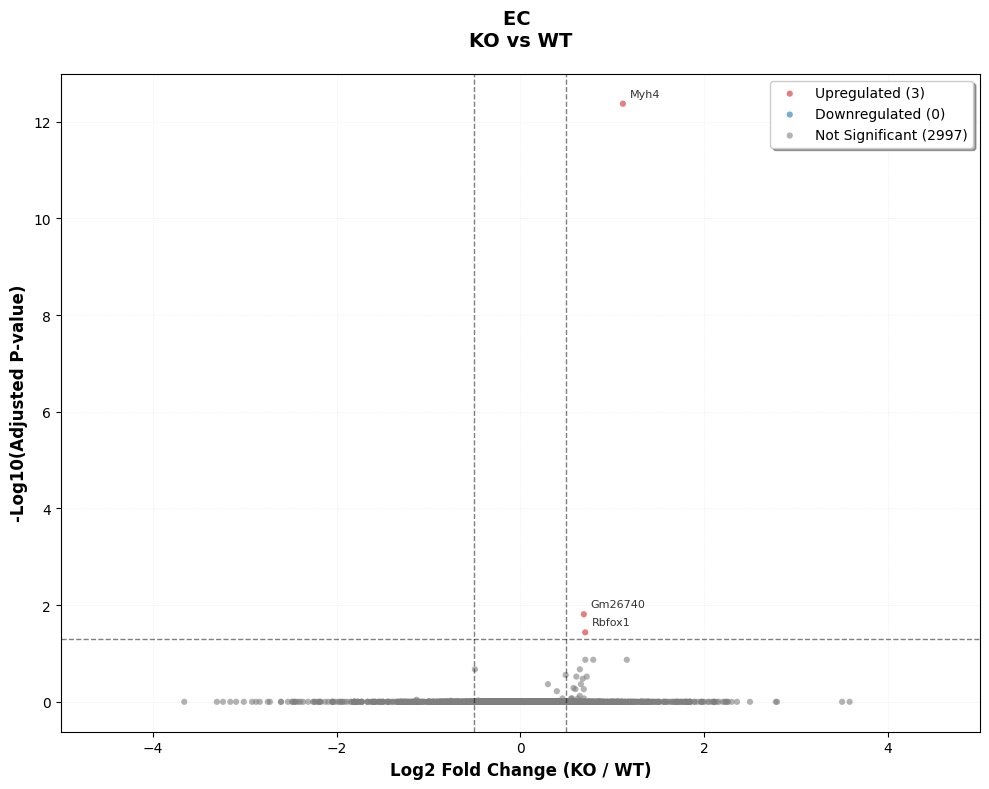


Creating plot for FAPs...


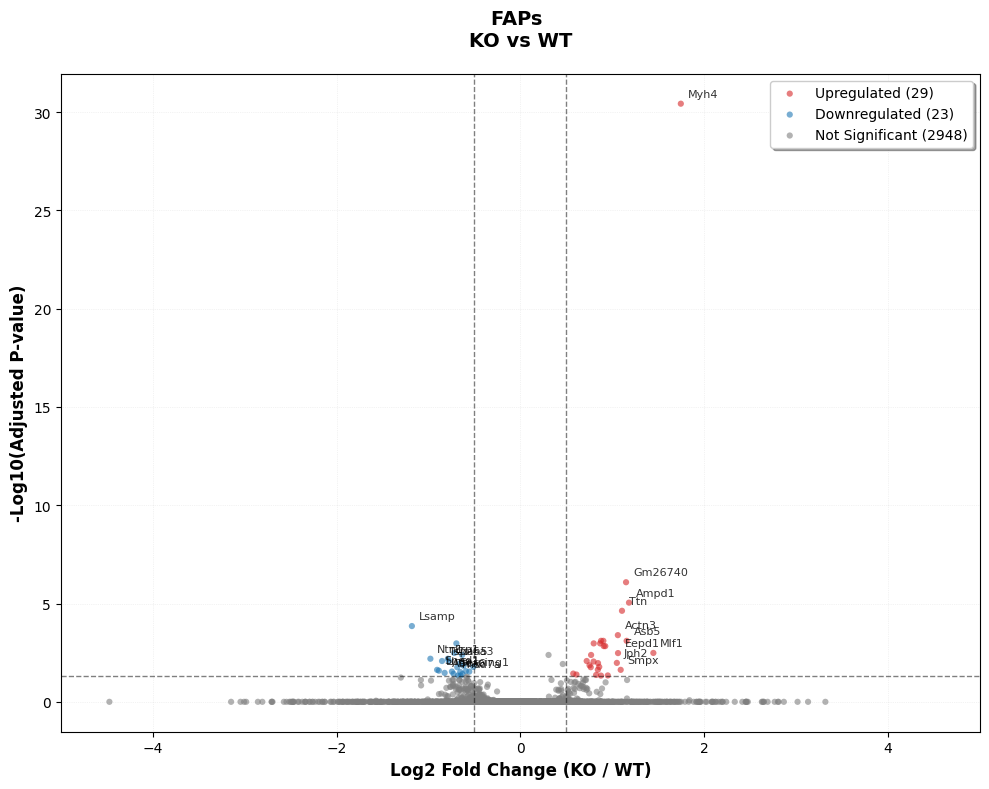


Creating plot for Fast IIB...


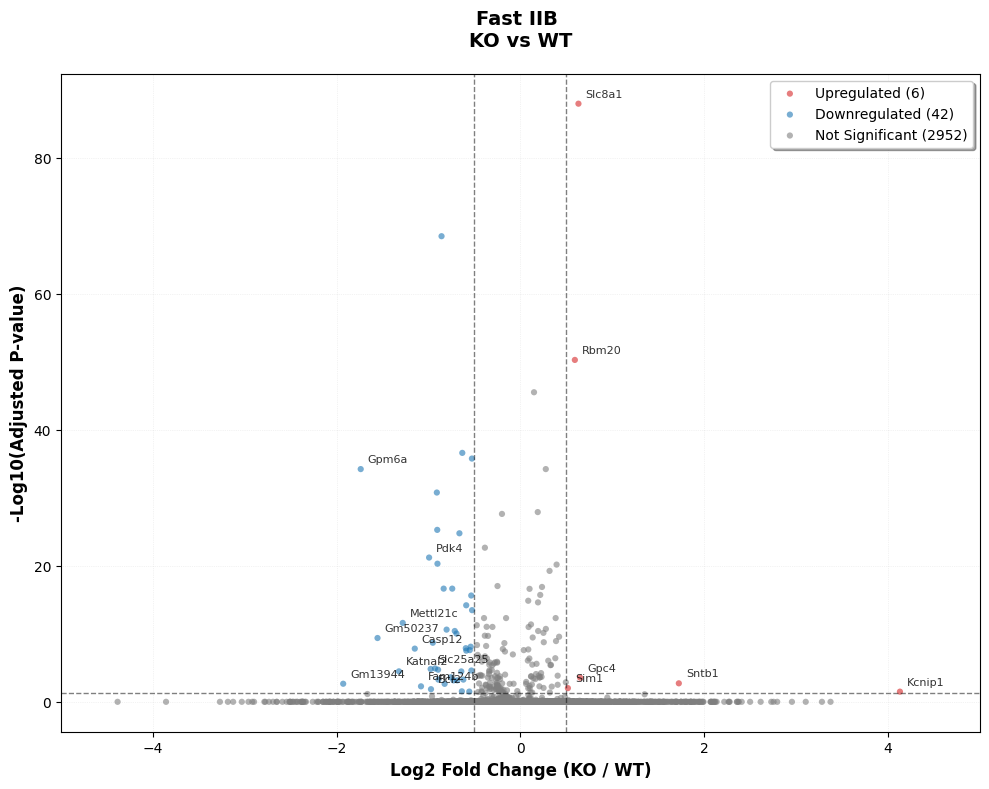


Creating plot for Fast IIX...


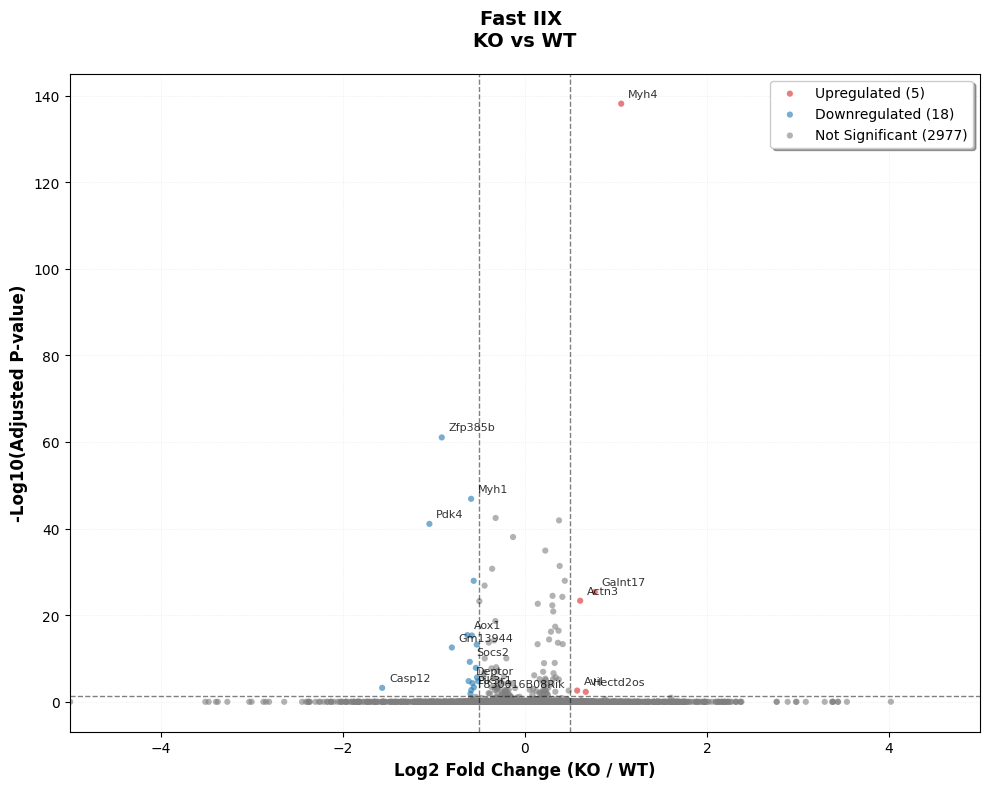


Creating plot for MTJ...


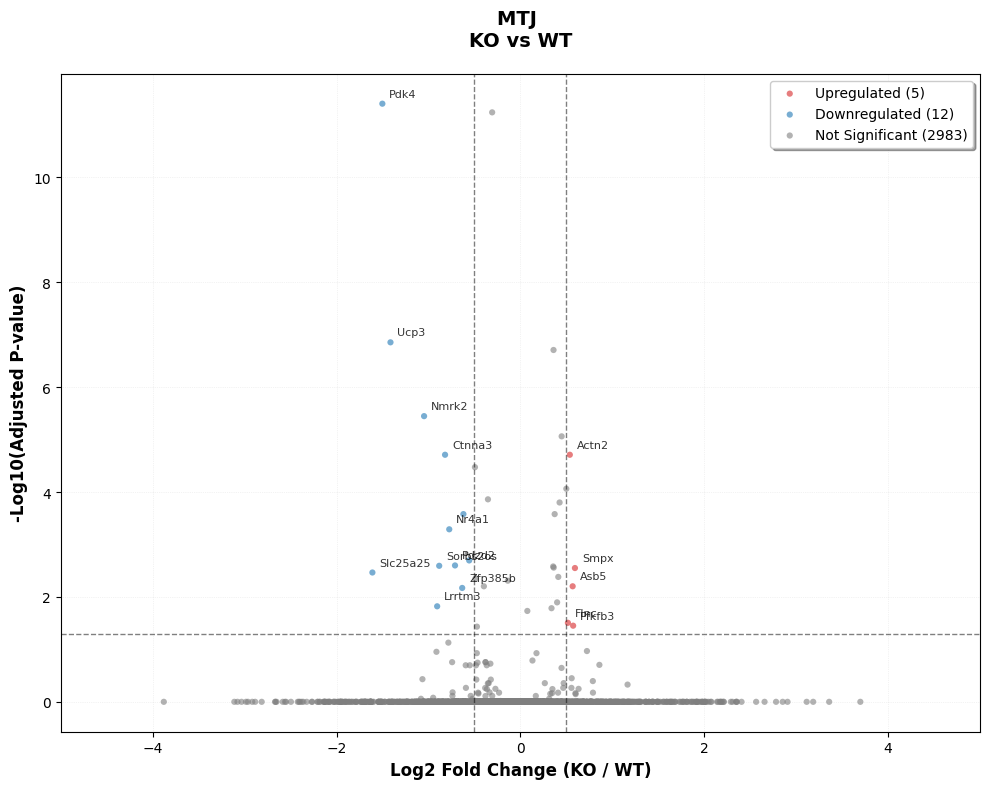


Creating plot for Macrophages...


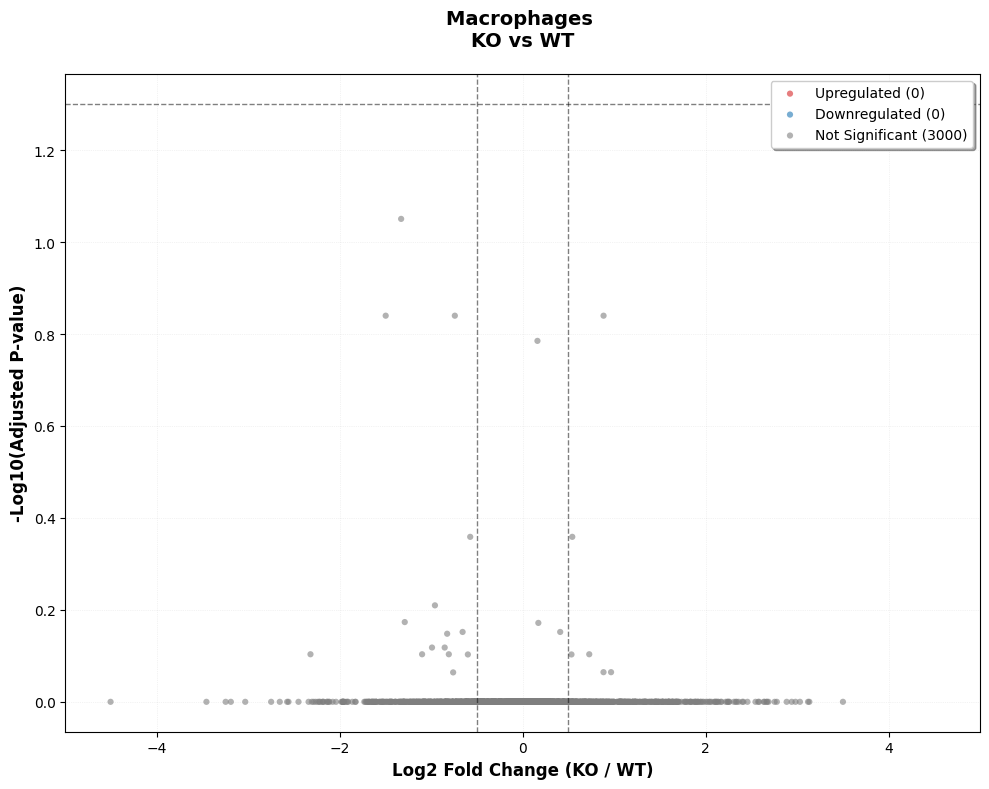


Creating plot for NMJ...


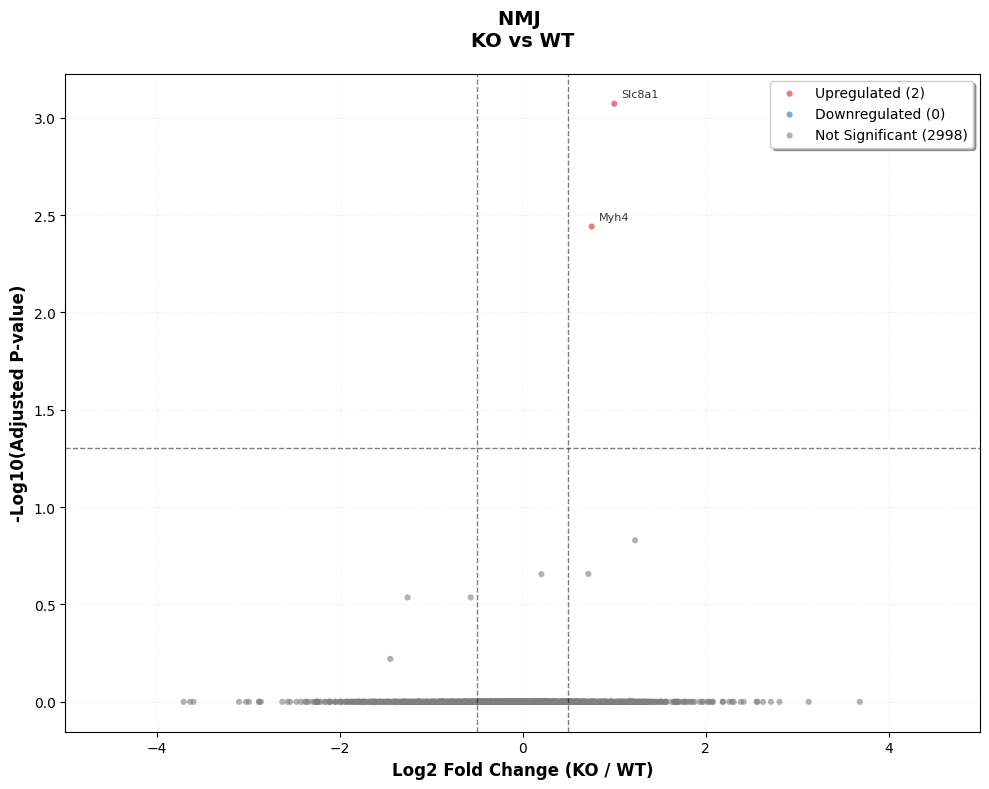


Creating plot for Pericyte...


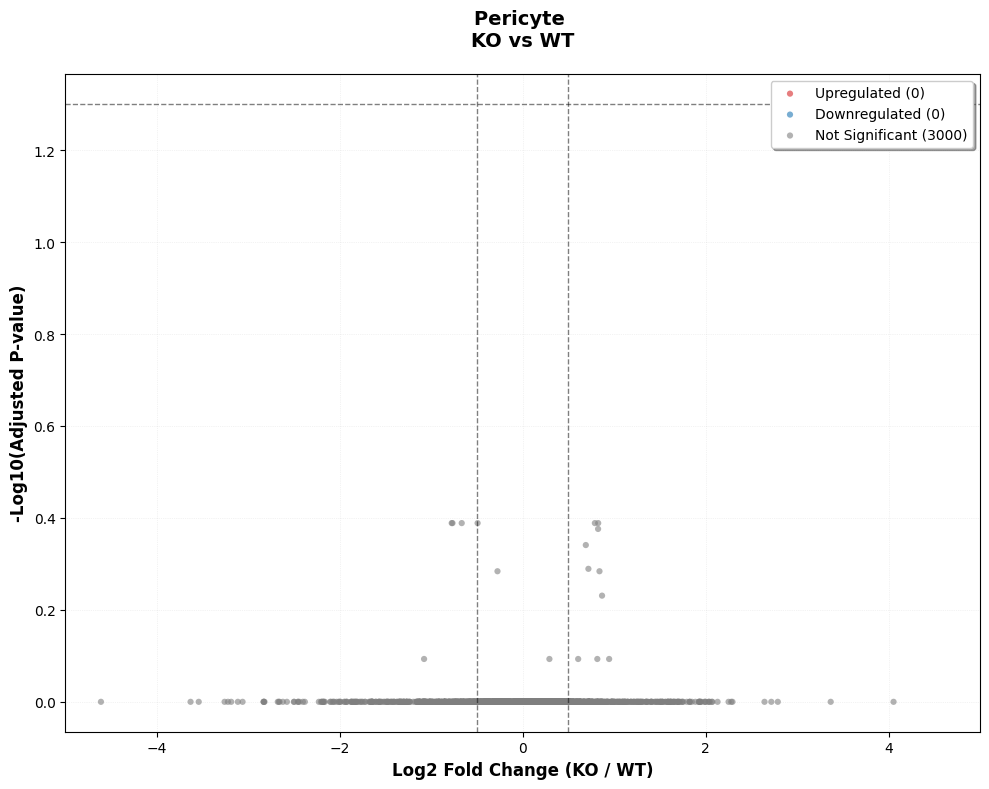


Creating plot for Skeleton MuSc...


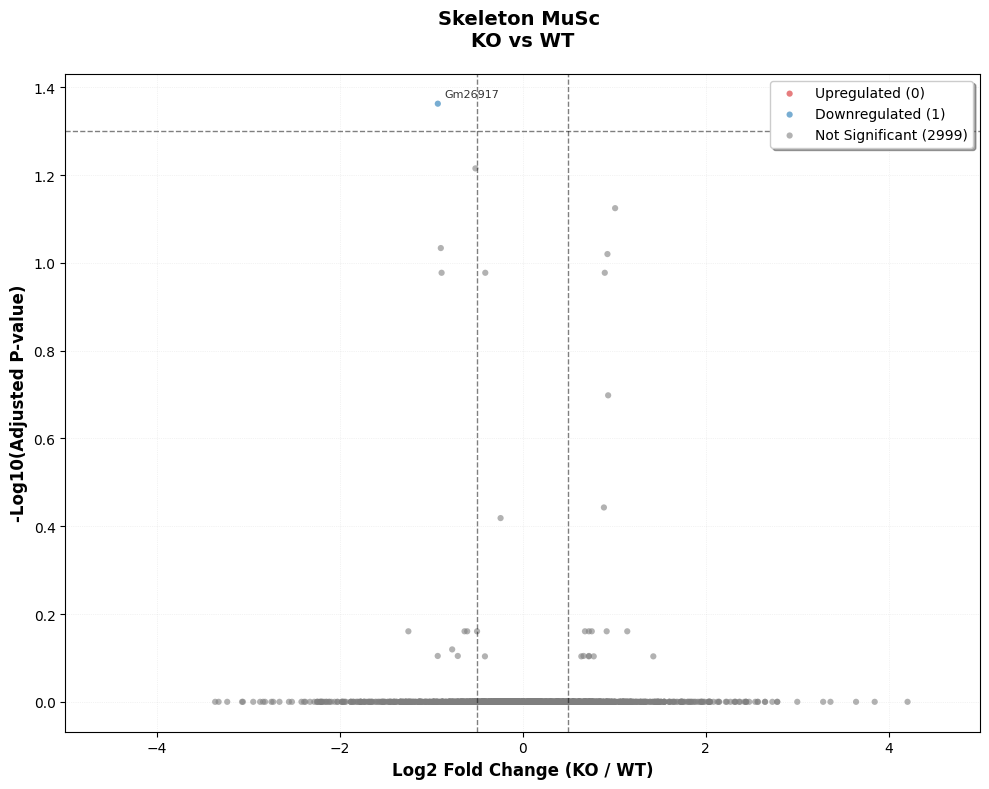


Creating plot for Tendon...


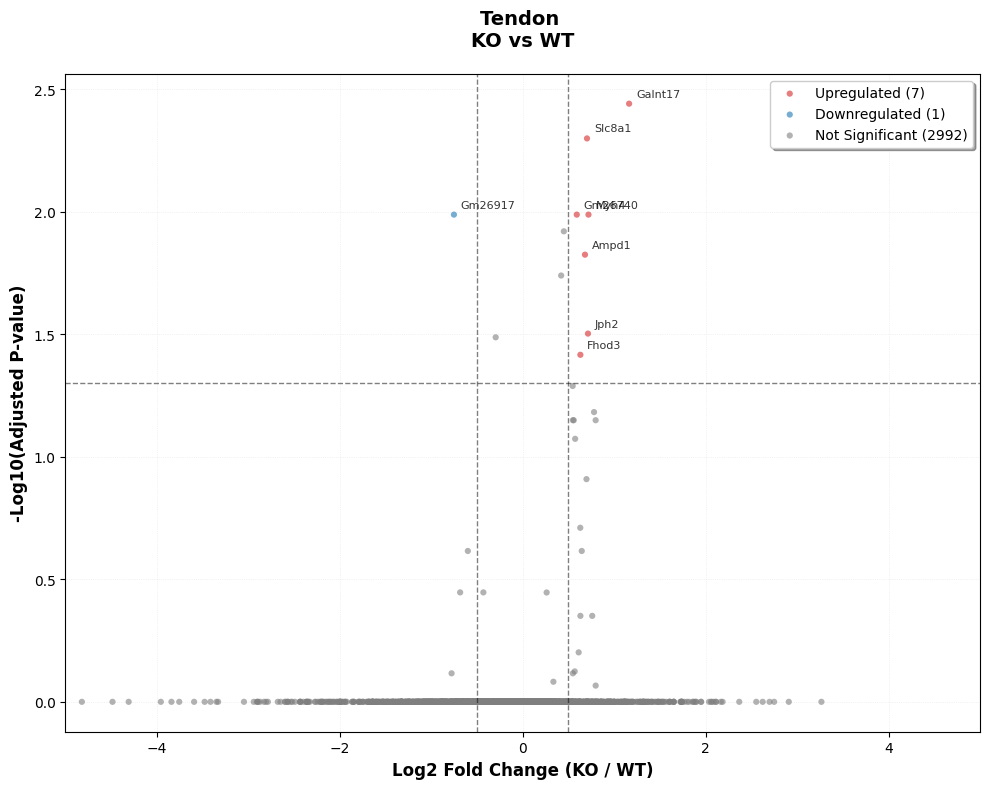

In [17]:
# Generate volcano plots for all cell types
for cell_type, degs in ko_wt_results.items():
    print(f"\nCreating plot for {cell_type}...")
    create_volcano_plot(degs, cell_type, top_n=10, title='', save=False)